# NSL-KDD Network Intrusion Detection — Tabular Data Poisoning

This notebook extends the poisoning budget analysis to **tabular, structured data**
using the NSL-KDD network intrusion detection dataset. Unlike the text-based
experiments in the main notebook, NSL-KDD consists of 41 numerical and categorical
network connection features — requiring a different preprocessing pipeline but
the same poisoning logic.

## Dataset
NSL-KDD contains network traffic records labeled as either normal or one of four
attack categories:
- **DoS** — Denial of Service (e.g. SYN flood)
- **Probe** — Surveillance and port scanning
- **R2L** — Unauthorized remote access
- **U2R** — Privilege escalation to root

## Experiment design
We run both untargeted and targeted label-flipping attacks, mirroring the
methodology from the main notebook:
- **Untargeted:** random label flips across all classes
- **Targeted (binary):** `attack → normal` — attacker hides intrusions as normal traffic
- **Targeted (multi-class):** `DoS → normal` and `Probe → normal`

The test set remains completely clean throughout all experiments.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kaggle

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix,
)

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 40
np.random.seed(RANDOM_STATE)

# ── Kaggle dataset ────────────────────────────────────────────────────────────
NSLKDD_KAGGLE_DATASET = "hassan06/nslkdd"
NSLKDD_TRAIN_FILE     = "KDDTrain+.txt"
NSLKDD_TEST_FILE      = "KDDTest+.txt"
DATA_DIR              = Path("data/nslkdd")

# ── Experiment settings ───────────────────────────────────────────────────────
POISONING_BUDGETS = [0.0, 0.01, 0.05, 0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45]
TARGETED_BUDGETS  = [0.0, 0.01, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
TEST_SIZE         = 0.20

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

## Step 1: Data Loading

NSL-KDD has no column headers in the raw files — we supply them manually.
The dataset contains 41 features plus a label column. Three columns are
categorical (`protocol_type`, `service`, `flag`) and the rest are numerical.
The original label column contains specific attack names (e.g. `neptune`, `portsweep`)
which we map to five coarse categories: `normal`, `DoS`, `Probe`, `R2L`, `U2R`.
For binary classification we further collapse these to `normal` vs `attack`.

In [3]:
# ── Column names (41 features + label + difficulty score) ────────────────────
COL_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

# ── Attack → coarse category mapping ─────────────────────────────────────────
ATTACK_MAP = {
    "normal":          "normal",
    "back":            "DoS",   "land":          "DoS",
    "neptune":         "DoS",   "pod":           "DoS",
    "smurf":           "DoS",   "teardrop":      "DoS",
    "mailbomb":        "DoS",   "apache2":       "DoS",
    "processtable":    "DoS",   "udpstorm":      "DoS",
    "ipsweep":         "Probe", "nmap":          "Probe",
    "portsweep":       "Probe", "satan":         "Probe",
    "mscan":           "Probe", "saint":         "Probe",
    "ftp_write":       "R2L",   "guess_passwd":  "R2L",
    "imap":            "R2L",   "multihop":      "R2L",
    "phf":             "R2L",   "spy":           "R2L",
    "warezclient":     "R2L",   "warezmaster":   "R2L",
    "sendmail":        "R2L",   "named":         "R2L",
    "snmpgetattack":   "R2L",   "snmpguess":     "R2L",
    "xlock":           "R2L",   "xsnoop":        "R2L",
    "worm":            "R2L",   "buffer_overflow": "U2R",
    "loadmodule":      "U2R",   "perl":          "U2R",
    "rootkit":         "U2R",   "httptunnel":    "U2R",
    "ps":              "U2R",   "sqlattack":     "U2R",
    "xterm":           "U2R",
}

CATEGORICAL_COLS = ["protocol_type", "service", "flag"]

def _download_if_needed(dest_dir: Path) -> None:
    dest_dir.mkdir(parents=True, exist_ok=True)
    if not (dest_dir / NSLKDD_TRAIN_FILE).exists():
        print(f"[Kaggle] Downloading '{NSLKDD_KAGGLE_DATASET}' → {dest_dir}")
        kaggle.api.authenticate()
        kaggle.api.dataset_download_files(
            NSLKDD_KAGGLE_DATASET, path=str(dest_dir), unzip=True, quiet=False
        )

def load_nslkdd(mode: str = "binary") -> pd.DataFrame:
    """
    Load and combine train+test splits into one DataFrame.
    mode='binary'     → label column: 'normal' vs 'attack'
    mode='multiclass' → label column: 'normal', 'DoS', 'Probe', 'R2L', 'U2R'
    """
    _download_if_needed(DATA_DIR)

    dfs = []
    for fname in [NSLKDD_TRAIN_FILE, NSLKDD_TEST_FILE]:
        df = pd.read_csv(DATA_DIR / fname, header=None, names=COL_NAMES)
        dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)
    df = df.drop(columns=["difficulty", "num_outbound_cmds"], errors="ignore")

    # Map specific attack names → coarse categories
    df["label_5"] = df["label"].map(ATTACK_MAP).fillna("unknown")

    # Binary label
    df["label_binary"] = df["label_5"].apply(
        lambda x: "normal" if x == "normal" else "attack"
    )

    if mode == "binary":
        df["label"] = df["label_binary"]
    else:
        df["label"] = df["label_5"]

    return df.drop(columns=["label_binary", "label_5"])

# ── Load both versions ────────────────────────────────────────────────────────
df_binary     = load_nslkdd(mode="binary")
df_multiclass = load_nslkdd(mode="multiclass")

print(f"Binary     — samples: {len(df_binary):,}  | classes: {df_binary['label'].value_counts().to_dict()}")
print(f"Multi-class — samples: {len(df_multiclass):,} | classes: {df_multiclass['label'].value_counts().to_dict()}")

[Kaggle] Downloading 'hassan06/nslkdd' → data\nslkdd
Dataset URL: https://www.kaggle.com/datasets/hassan06/nslkdd


100%|██████████| 13.9M/13.9M [00:01<00:00, 13.9MB/s]



Binary     — samples: 148,517  | classes: {'normal': 77054, 'attack': 71463}
Multi-class — samples: 148,517 | classes: {'normal': 77054, 'DoS': 53385, 'Probe': 14077, 'R2L': 3749, 'U2R': 252}


## Step 2: Preprocessing and Feature Extraction

Tabular preprocessing differs from the text pipeline in the main notebook:
- **Categorical columns** (`protocol_type`, `service`, `flag`) are one-hot encoded
  with `pd.get_dummies()` — replacing the TF-IDF vectorizer
- **Numerical columns** are scaled with `StandardScaler` — essential for
  Logistic Regression on features with very different ranges (e.g. `src_bytes`
  can reach 10^9 while `land` is binary)
- The same **80/20 stratified split** and `RANDOM_STATE=40` are used for
  consistency with the main notebook

In [4]:
from scipy.sparse import csr_matrix, hstack

def preprocess_and_vectorize_nslkdd(
    df: pd.DataFrame,
    test_size: float = TEST_SIZE,
    random_state: int = RANDOM_STATE,
):
    """One-hot encode categoricals + StandardScale numerics."""
    df = df.copy()

    # Separate label
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df["label"])
    num_classes = len(label_encoder.classes_)
    df = df.drop(columns=["label"])

    # One-hot encode categorical columns
    df_encoded = pd.get_dummies(df, columns=CATEGORICAL_COLS)

    # Scale numerical columns
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_encoded.astype(float))
    X = csr_matrix(X_scaled)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )
    return X_train, X_test, y_train, y_test, num_classes, label_encoder

# ── Preprocess both versions ──────────────────────────────────────────────────
X_train_b, X_test_b, y_train_b, y_test_b, n_classes_b, le_b = \
    preprocess_and_vectorize_nslkdd(df_binary)

X_train_m, X_test_m, y_train_m, y_test_m, n_classes_m, le_m = \
    preprocess_and_vectorize_nslkdd(df_multiclass)

print(f"Binary     — train: {X_train_b.shape}, test: {X_test_b.shape}, classes: {le_b.classes_}")
print(f"Multi-class — train: {X_train_m.shape}, test: {X_test_m.shape}, classes: {le_m.classes_}")

Binary     — train: (118813, 121), test: (29704, 121), classes: ['attack' 'normal']
Multi-class — train: (118813, 121), test: (29704, 121), classes: ['DoS' 'Probe' 'R2L' 'U2R' 'normal']


## Step 3: Poisoning Logic

The poisoning functions are identical to the main notebook — copied here
unchanged to make this notebook self-contained. This is intentional: the
goal is to show that the same attack logic produces different outcomes on
tabular vs text data.

### Untargeted
Uniformly samples ⌊C·n⌋ training indices and flips labels randomly.

### Targeted
Flips only samples of the source class to the target class, capped at 30%
of the source class size to preserve training validity.

In [5]:
def apply_label_flipping(
    y_train: np.ndarray,
    budget: float,
    num_classes: int,
    random_state: int = RANDOM_STATE,
) -> np.ndarray:
    y_poisoned = np.array(y_train, copy=True)
    n = len(y_poisoned)
    if budget <= 0 or n == 0:
        return y_poisoned
    n_poison = max(int(np.floor(budget * n)), 1)
    n_poison = min(n_poison, n)
    rng = np.random.default_rng(random_state)
    poison_indices = rng.choice(n, size=n_poison, replace=False)
    for idx in poison_indices:
        original = y_poisoned[idx]
        if num_classes == 2:
            y_poisoned[idx] = 1 - original
        else:
            candidates = [c for c in range(num_classes) if c != original]
            y_poisoned[idx] = rng.choice(candidates)
    return y_poisoned


def apply_targeted_poison(
    y_train: np.ndarray,
    budget: float,
    source_class: int,
    target_class: int,
    random_state: int = RANDOM_STATE,
) -> np.ndarray:
    y_poisoned = np.array(y_train, copy=True)
    n = len(y_poisoned)
    if budget <= 0 or n == 0:
        return y_poisoned
    n_budget = max(int(np.floor(budget * n)), 1)
    source_indices = np.where(y_train == source_class)[0]
    max_flippable = int(len(source_indices) * 0.30)
    n_flip = min(n_budget, max_flippable)
    if n_flip == 0:
        return y_poisoned
    if len(source_indices) - n_flip == 0:
        return y_poisoned
    rng = np.random.default_rng(random_state)
    flip_indices = rng.choice(source_indices, size=n_flip, replace=False)
    y_poisoned[flip_indices] = target_class
    return y_poisoned

## Step 4: Experimental Loops

### 4.1 Untargeted poisoning
Runs across all budgets for both binary and multi-class versions.

### 4.2 Targeted poisoning
Three targeted scenarios mirroring the real-world attacker model:
- **Binary:** `attack → normal` — attacker hides all intrusions as normal traffic
- **Multi-class (primary):** `DoS → normal` — most common attack type hidden
- **Multi-class (secondary):** `Probe → normal` — reconnaissance traffic hidden

In [6]:
def build_classifier(random_state: int = RANDOM_STATE) -> LogisticRegression:
    return LogisticRegression(max_iter=1000, solver="lbfgs", random_state=random_state)

def evaluate(y_test, y_pred, average) -> dict:
    return {
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average=average, zero_division=0),
        "recall":    recall_score(y_test, y_pred, average=average, zero_division=0),
        "f1":        f1_score(y_test, y_pred, average=average, zero_division=0),
    }

def run_poisoning_experiment(
    X_train, X_test, y_train, y_test,
    num_classes, dataset_name,
    budgets=None, metric_average="binary",
) -> pd.DataFrame:
    if budgets is None:
        budgets = POISONING_BUDGETS
    rows = []
    for budget in budgets:
        y_p = apply_label_flipping(y_train, budget, num_classes)
        clf = build_classifier()
        clf.fit(X_train, y_p)
        scores = evaluate(y_test, clf.predict(X_test), metric_average)
        for metric, value in scores.items():
            rows.append({"dataset": dataset_name, "attack": "untargeted",
                         "flip": "random", "budget": budget,
                         "budget_pct": budget * 100, "metric": metric, "score": value})
    return pd.DataFrame(rows)

def run_targeted_poisoning_experiment(
    X_train, X_test, y_train, y_test,
    source_label, target_label, le,
    num_classes, dataset_name,
    metric_average="binary", budgets=None,
) -> pd.DataFrame:
    if budgets is None:
        budgets = TARGETED_BUDGETS
    source_class = le.transform([source_label])[0]
    target_class = le.transform([target_label])[0]
    flip_label = f"{source_label}→{target_label}"
    rows = []
    for budget in budgets:
        y_p = apply_targeted_poison(y_train, budget, source_class, target_class)
        clf = build_classifier()
        clf.fit(X_train, y_p)
        scores = evaluate(y_test, clf.predict(X_test), metric_average)
        for metric, value in scores.items():
            rows.append({"dataset": dataset_name, "attack": "targeted",
                         "flip": flip_label, "budget": budget,
                         "budget_pct": budget * 100, "metric": metric, "score": value})
    return pd.DataFrame(rows)

# ── Run all experiments ───────────────────────────────────────────────────────
results_binary = run_poisoning_experiment(
    X_train_b, X_test_b, y_train_b, y_test_b,
    num_classes=n_classes_b, dataset_name="NSL-KDD (Binary)",
    metric_average="binary",
)
results_multi = run_poisoning_experiment(
    X_train_m, X_test_m, y_train_m, y_test_m,
    num_classes=n_classes_m, dataset_name="NSL-KDD (Multi-Class)",
    metric_average="macro",
)
results_binary_targeted = run_targeted_poisoning_experiment(
    X_train_b, X_test_b, y_train_b, y_test_b,
    source_label="attack", target_label="normal",
    le=le_b, num_classes=n_classes_b,
    dataset_name="NSL-KDD (Binary)", metric_average="binary",
)
results_dos_targeted = run_targeted_poisoning_experiment(
    X_train_m, X_test_m, y_train_m, y_test_m,
    source_label="DoS", target_label="normal",
    le=le_m, num_classes=n_classes_m,
    dataset_name="NSL-KDD (Multi-Class)", metric_average="macro",
)
results_probe_targeted = run_targeted_poisoning_experiment(
    X_train_m, X_test_m, y_train_m, y_test_m,
    source_label="Probe", target_label="normal",
    le=le_m, num_classes=n_classes_m,
    dataset_name="NSL-KDD (Multi-Class)", metric_average="macro",
)

results_all = pd.concat([
    results_binary,
    results_multi,
    results_binary_targeted,
    results_dos_targeted,
    results_probe_targeted,
], ignore_index=True)

results_all

,dataset,attack,flip,budget,budget_pct,metric,score
0,NSL-KDD (Binary),untargeted,random,0.00,0.0,accuracy,0.957480
1,NSL-KDD (Binary),untargeted,random,0.00,0.0,precision,0.950344
2,NSL-KDD (Binary),untargeted,random,0.00,0.0,recall,0.968659
3,NSL-KDD (Binary),untargeted,random,0.00,0.0,f1,0.959414
4,NSL-KDD (Binary),untargeted,random,0.01,1.0,accuracy,0.956100
...,...,...,...,...,...,...,...
207,NSL-KDD (Multi-Class),targeted,Probe→normal,0.60,60.0,f1,0.871280
208,NSL-KDD (Multi-Class),targeted,Probe→normal,0.70,70.0,accuracy,0.964281
209,NSL-KDD (Multi-Class),targeted,Probe→normal,0.70,70.0,precision,0.928375
210,NSL-KDD (Multi-Class),targeted,Probe→normal,0.70,70.0,recall,0.827234


## Step 5: Results and Visualization

All five plots mirror the main notebook exactly, enabling direct cross-domain
comparison between email spam (Enron), URL classification (MURLs), and
network intrusion detection (NSL-KDD).

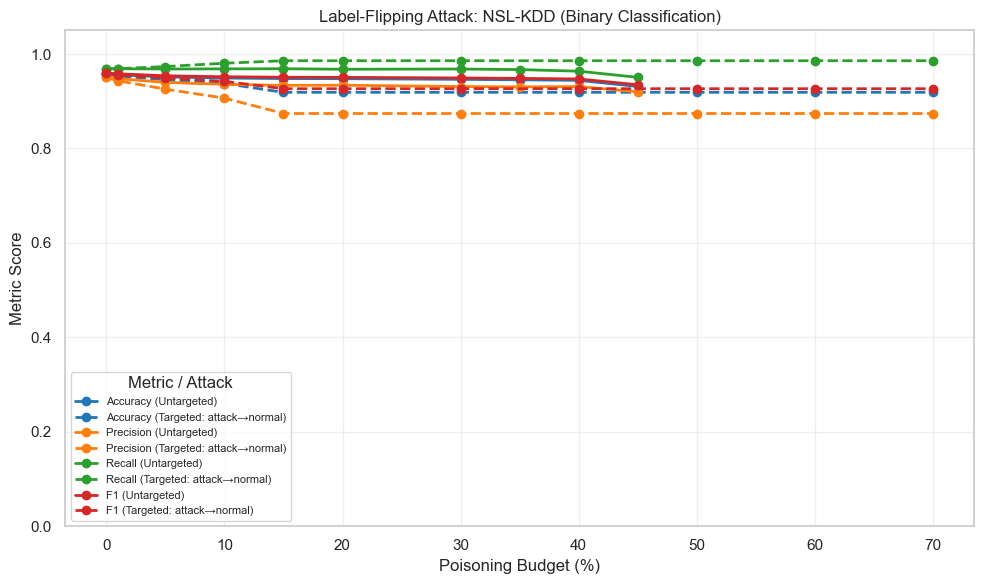

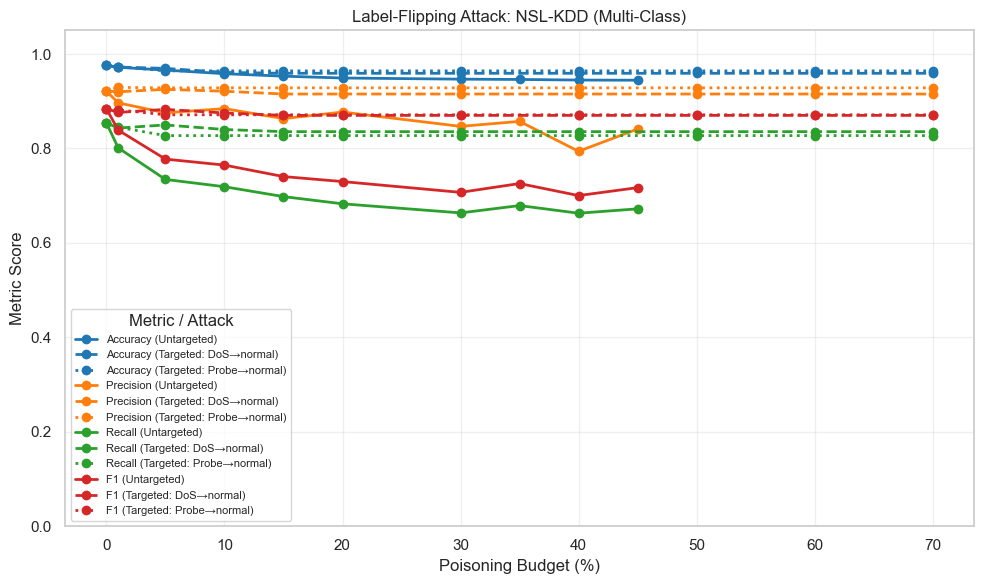

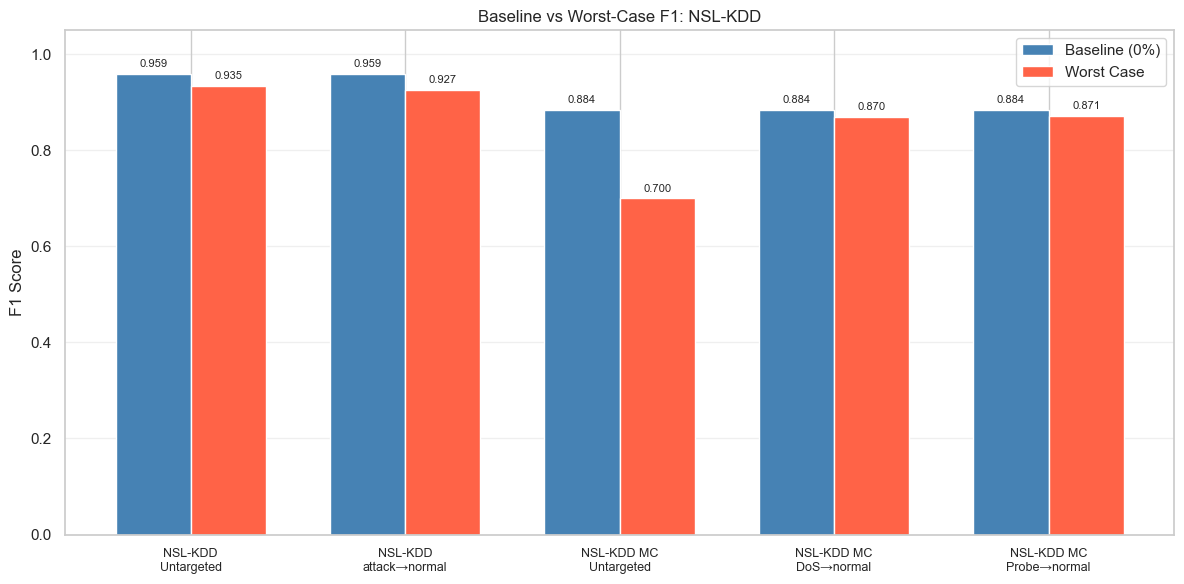

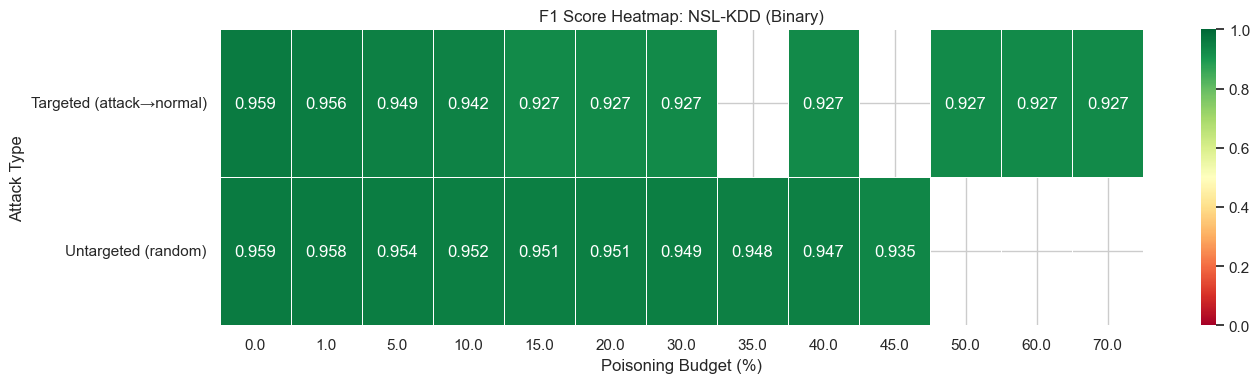

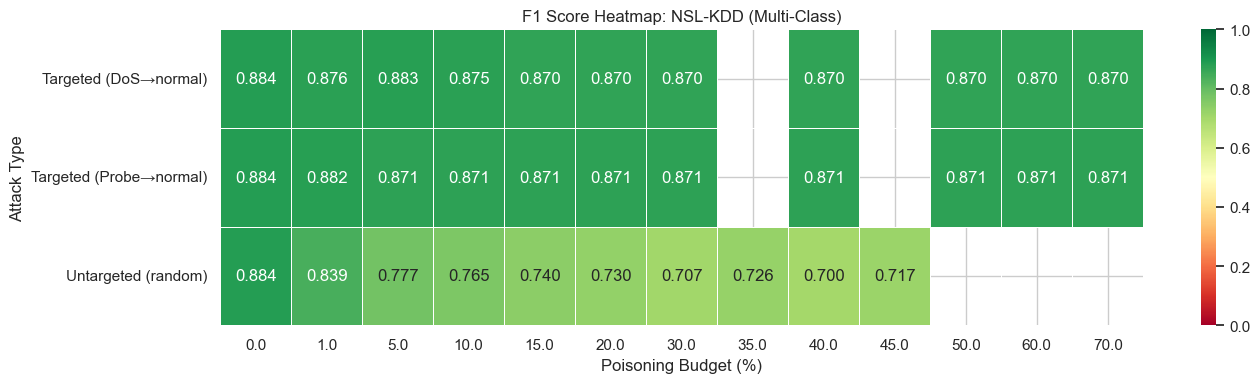

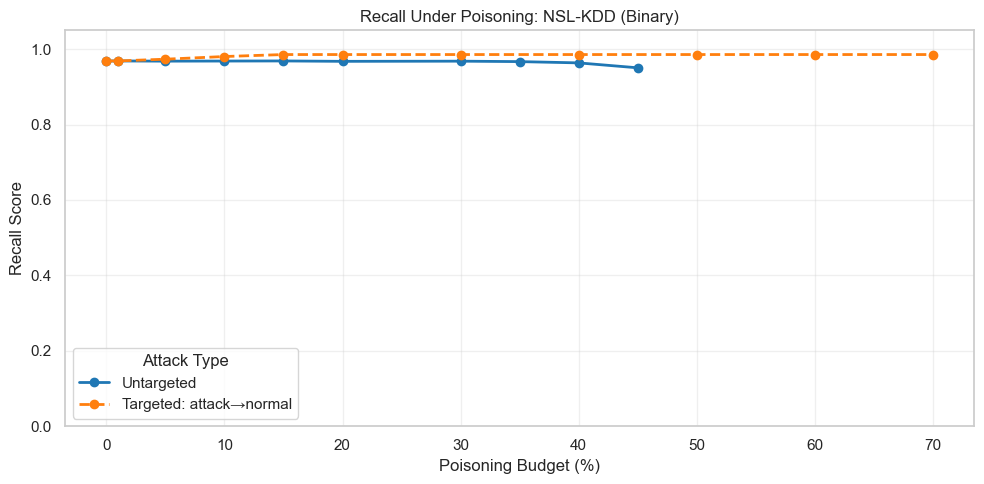

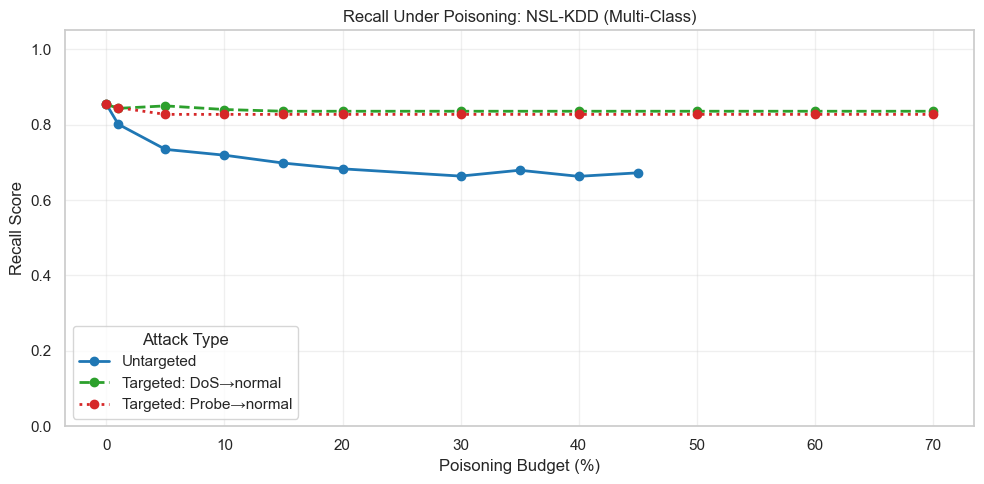

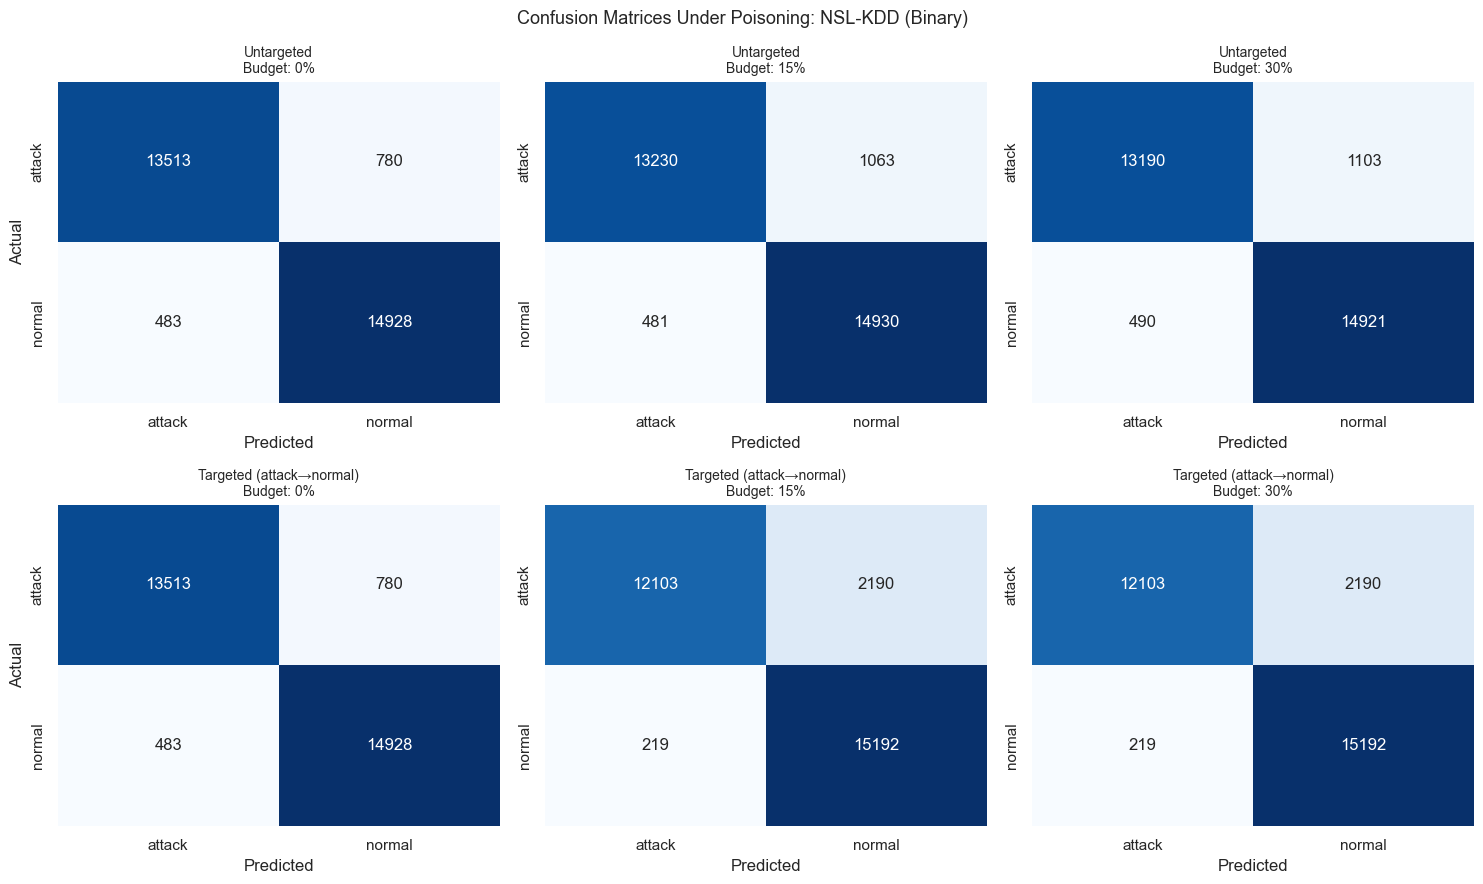

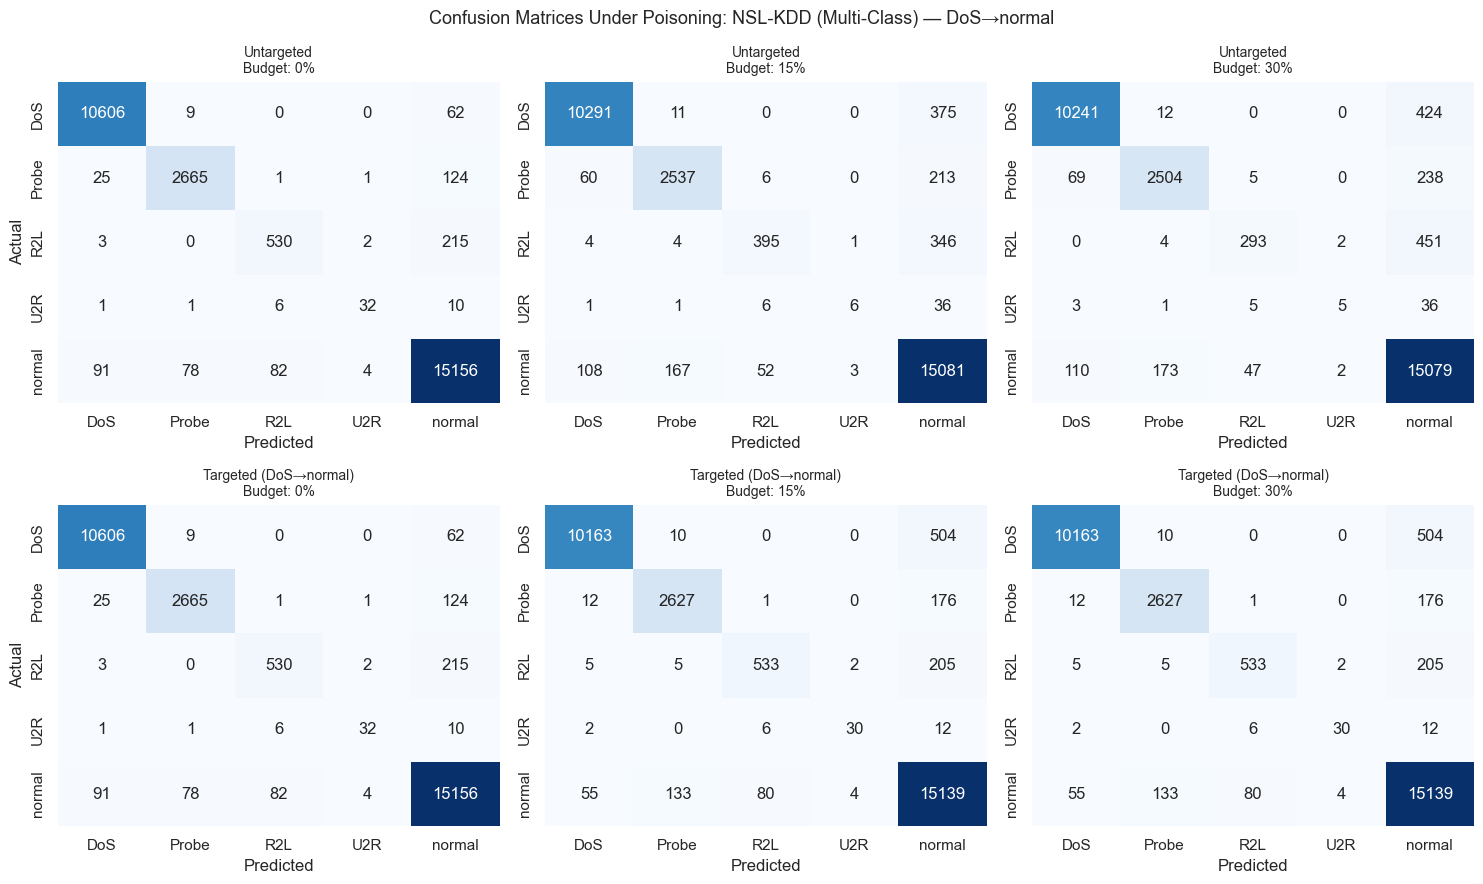

In [7]:
# ── Visual 1: Degradation line plots ─────────────────────────────────────────
def plot_poisoning_degradation(df, title, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    metrics_order = ["accuracy", "precision", "recall", "f1"]
    palette = sns.color_palette("tab10", n_colors=len(metrics_order))
    style_map = {
        "untargeted":    ("solid",  "Untargeted"),
        "attack→normal": ("dashed", "Targeted: attack→normal"),
        "DoS→normal":    ("dashed", "Targeted: DoS→normal"),
        "Probe→normal":  ("dotted", "Targeted: Probe→normal"),
    }
    for metric, color in zip(metrics_order, palette):
        mdf = df[df["metric"] == metric]
        for flip_key, (ls, flip_label) in style_map.items():
            if flip_key == "untargeted":
                subset = mdf[mdf["attack"] == "untargeted"]
            else:
                subset = mdf[(mdf["attack"] == "targeted") & (mdf["flip"] == flip_key)]
            if subset.empty:
                continue
            ax.plot(subset.sort_values("budget_pct")["budget_pct"],
                    subset.sort_values("budget_pct")["score"],
                    marker="o", linewidth=2, linestyle=ls,
                    label=f"{metric.capitalize()} ({flip_label})", color=color)
    ax.set_xlabel("Poisoning Budget (%)")
    ax.set_ylabel("Metric Score")
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.legend(title="Metric / Attack", fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_poisoning_degradation(
    results_all[results_all["dataset"] == "NSL-KDD (Binary)"],
    title="Label-Flipping Attack: NSL-KDD (Binary Classification)",
    save_path=Path("nslkdd_binary_poisoning.png"),
)
plot_poisoning_degradation(
    results_all[results_all["dataset"] == "NSL-KDD (Multi-Class)"],
    title="Label-Flipping Attack: NSL-KDD (Multi-Class)",
    save_path=Path("nslkdd_multi_poisoning.png"),
)

# ── Visual 2: Baseline vs Worst-Case bar chart ────────────────────────────────
def plot_baseline_vs_poisoned(df, save_path=None):
    configs = [
        ("NSL-KDD (Binary)",      "untargeted", "random",          "NSL-KDD\nUntargeted"),
        ("NSL-KDD (Binary)",      "targeted",   "attack→normal",   "NSL-KDD\nattack→normal"),
        ("NSL-KDD (Multi-Class)", "untargeted", "random",          "NSL-KDD MC\nUntargeted"),
        ("NSL-KDD (Multi-Class)", "targeted",   "DoS→normal",      "NSL-KDD MC\nDoS→normal"),
        ("NSL-KDD (Multi-Class)", "targeted",   "Probe→normal",    "NSL-KDD MC\nProbe→normal"),
    ]
    baselines, worst_cases, labels = [], [], []
    for dataset, attack, flip, label in configs:
        subset = df[(df["dataset"] == dataset) & (df["attack"] == attack) &
                    (df["flip"] == flip) & (df["metric"] == "f1")].sort_values("budget_pct")
        if subset.empty:
            continue
        baselines.append(subset[subset["budget_pct"] == 0]["score"].values[0])
        worst_cases.append(subset["score"].min())
        labels.append(label)
    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width/2, baselines,   width, label="Baseline (0%)",  color="steelblue")
    bars2 = ax.bar(x + width/2, worst_cases, width, label="Worst Case",     color="tomato")
    for bar in bars1 + bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("F1 Score")
    ax.set_title("Baseline vs Worst-Case F1: NSL-KDD")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_baseline_vs_poisoned(results_all, save_path=Path("nslkdd_baseline_vs_poisoned.png"))

# ── Visual 3: F1 Heatmaps ────────────────────────────────────────────────────
def plot_f1_heatmap(df, dataset_name, save_path=None):
    subset = df[(df["dataset"] == dataset_name) & (df["metric"] == "f1")].copy()
    subset["attack_label"] = subset["flip"].apply(
        lambda x: "Untargeted (random)" if x == "random" else f"Targeted ({x})"
    )
    pivot = subset.pivot_table(index="attack_label", columns="budget_pct", values="score")
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn",
                vmin=0, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(f"F1 Score Heatmap: {dataset_name}")
    ax.set_xlabel("Poisoning Budget (%)")
    ax.set_ylabel("Attack Type")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_f1_heatmap(results_all, "NSL-KDD (Binary)",      save_path=Path("nslkdd_binary_heatmap.png"))
plot_f1_heatmap(results_all, "NSL-KDD (Multi-Class)", save_path=Path("nslkdd_multi_heatmap.png"))

# ── Visual 4: Recall comparison ───────────────────────────────────────────────
def plot_recall_comparison(df, dataset_name, save_path=None):
    subset = df[(df["dataset"] == dataset_name) & (df["metric"] == "recall")]
    style_map = {
        "random":          ("solid",  "Untargeted"),
        "attack→normal":   ("dashed", "Targeted: attack→normal"),
        "DoS→normal":      ("dashed", "Targeted: DoS→normal"),
        "Probe→normal":    ("dotted", "Targeted: Probe→normal"),
    }
    fig, ax = plt.subplots(figsize=(10, 5))
    palette = sns.color_palette("tab10", n_colors=len(style_map))
    for (flip_key, (ls, flip_label)), color in zip(style_map.items(), palette):
        s = subset[subset["flip"] == flip_key].sort_values("budget_pct")
        if s.empty:
            continue
        ax.plot(s["budget_pct"], s["score"], marker="o", linewidth=2,
                linestyle=ls, label=flip_label, color=color)
    ax.set_xlabel("Poisoning Budget (%)")
    ax.set_ylabel("Recall Score")
    ax.set_title(f"Recall Under Poisoning: {dataset_name}")
    ax.set_ylim(0, 1.05)
    ax.legend(title="Attack Type")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_recall_comparison(results_all, "NSL-KDD (Binary)",      save_path=Path("nslkdd_binary_recall.png"))
plot_recall_comparison(results_all, "NSL-KDD (Multi-Class)", save_path=Path("nslkdd_multi_recall.png"))

# ── Visual 5: Confusion matrices ─────────────────────────────────────────────
def plot_confusion_matrices(
    X_train, X_test, y_train, y_test, le,
    source_label, target_label, dataset_name,
    metric_average="binary", budgets_to_show=[0.0, 0.15, 0.30], save_path=None,
):
    source_class = le.transform([source_label])[0]
    target_class = le.transform([target_label])[0]
    class_names  = le.classes_
    n_budgets    = len(budgets_to_show)
    fig, axes    = plt.subplots(2, n_budgets, figsize=(5 * n_budgets, 9))
    fig.suptitle(f"Confusion Matrices Under Poisoning: {dataset_name}", fontsize=13)
    for row, attack_type in enumerate(["untargeted", "targeted"]):
        for col_idx, budget in enumerate(budgets_to_show):
            ax = axes[row, col_idx]
            if attack_type == "untargeted":
                y_p = apply_label_flipping(y_train, budget, len(class_names))
            else:
                y_p = apply_targeted_poison(y_train, budget, source_class, target_class)
            clf = build_classifier()
            clf.fit(X_train, y_p)
            y_pred = clf.predict(X_test)
            cm = confusion_matrix(y_test, y_pred, labels=le.transform(class_names))
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                        xticklabels=class_names, yticklabels=class_names,
                        ax=ax, cbar=False)
            label = "Untargeted" if attack_type == "untargeted" else f"Targeted ({source_label}→{target_label})"
            ax.set_title(f"{label}\nBudget: {int(budget * 100)}%", fontsize=10)
            ax.set_xlabel("Predicted")
            ax.set_ylabel("Actual" if col_idx == 0 else "")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_confusion_matrices(
    X_train_b, X_test_b, y_train_b, y_test_b, le=le_b,
    source_label="attack", target_label="normal",
    dataset_name="NSL-KDD (Binary)",
    metric_average="binary",
    budgets_to_show=[0.0, 0.15, 0.30],
    save_path=Path("nslkdd_binary_confusion.png"),
)
plot_confusion_matrices(
    X_train_m, X_test_m, y_train_m, y_test_m, le=le_m,
    source_label="DoS", target_label="normal",
    dataset_name="NSL-KDD (Multi-Class) — DoS→normal",
    metric_average="macro",
    budgets_to_show=[0.0, 0.15, 0.30],
    save_path=Path("nslkdd_multi_confusion_dos.png"),
)